In [1]:
import pandas as pd
import plot_likert
import matplotlib.pyplot as plt
import matplotlib as mpl

In [13]:
scale5 = [
    "task_clarity",
    "rating",
    "perceived_effort",
    "comfortable",
    "sequence_intuitive",
    "perceived_difficulty",
    "efficiency",
    "robot_facilitated",
    "robot_natural_interaction",
    "robot_timely",
    "interaction_fluidity",
    "robot_trajectory",
    "safety_effective",
    "gui_simple",
    "safety",
]
scale3 = [
    "reduced_robot_downtime",
    "robot_velocity",
    "robot_collision",
    "perceived_time",
]
scale2 = [
    "fatigue",
    "robot_obstacle",
]

In [15]:
# df = pd.read_csv("summary.csv")
# df.index = df.VAR
# df = df.fillna(0)

# data_all = df[["1","2","3","4","5"]]
# data5 = df[["1","2","3","4","5"]].loc[scale5]
# data3 = df[["1","3","5"]].loc[scale3]
# data2 = df[["1","5"]].loc[scale2]
# # display(data)
# TRANSPARENT = "#ffffff00"

# colors = {
#     "1": "firebrick",
#     "2": "lightcoral",
#     "3": "silver",
#     "4": "cornflowerblue",
#     "5": "darkblue",
# }

# for data in [data_all, data5, data3, data2][::-1]:

#     fig, ax = plt.subplots(figsize=(5, len(data)/3))
    
#     plot_likert.plot_counts(
#         data.fillna(0),
#         data.columns,
#         ax=ax,
#         legend=1,
#         colors=[TRANSPARENT]+[colors[c] for c in data.columns],
#         compute_percentages=True
#     )
#     plt.show()

/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(
/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(
/home/bportelli/venv8/lib/python3.8/site-packages/plot_liker

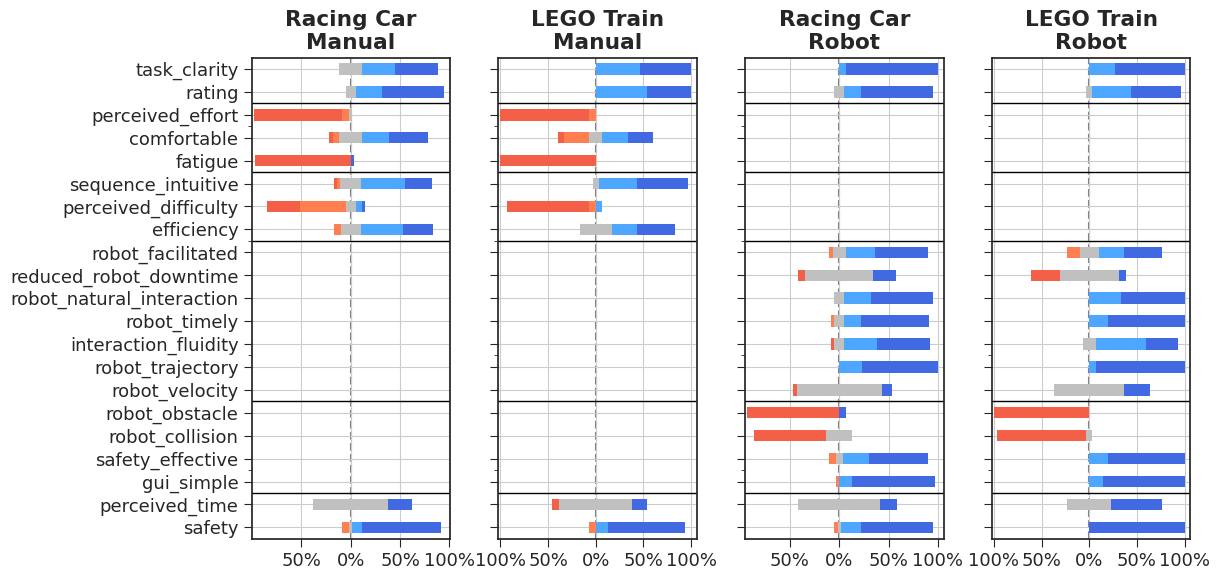

In [18]:
plt.style.use('seaborn-v0_8-ticks')
font = {
    'size' : 13
}
mpl.rc('font', **font)

colors = {
    "1": "#F36047",
    "2": "coral",
    "3": "silver",
    "4": "#4da6ff",
    "5": "RoyalBlue",
}

data = df_concat



fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(3*4, len(data)/15), sharey=True)

for idx, (PRODUCT, SETUP) in enumerate([
        ("Racing Car", "Manual"),
        ("LEGO Train", "Manual"),
        ("Racing Car", "Robot"),
        ("LEGO Train", "Robot"),
    ]):
    gdata = data[(data.SETUP==SETUP)&(data.PRODUCT==PRODUCT)]

    ax = axs[idx]

    gdata = gdata[["1","2","3","4","5"]]
    
    plot_likert.plot_counts(
        gdata.fillna(0),
        gdata.columns,
        ax=ax,
        legend=False,
        colors=[TRANSPARENT]+[colors[c] for c in gdata.columns],
        compute_percentages=True,
        xtick_interval=50,
    )

    for k in [1.5, 5.5, 12.5, 15.5, 18.5]:
        ax.axhline(k, lw=1, color="k")
    ax.set_title(f"{PRODUCT}\n{SETUP}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.grid(True)
    if idx != 0:
        pass
# plt.legend()
plt.tight_layout(pad=0.0)
plt.show()

In [25]:
df = pd.read_csv("summary.csv")
df.index = df.VAR
df = df.fillna(0)

manual_vars = set(df[df.SETUP == "Manual"].VAR.unique())
robot_vars = set(df[df.SETUP == "Robot"].VAR.unique())
manual_only = manual_vars - robot_vars
robot_only = robot_vars - manual_vars
print(manual_only)
print(robot_only)

new_data = []
for key in manual_only:
    item_1 = [key, "LEGO Train", "Robot"] + [0]*7
    item_2 = [key, "Racing Car", "Robot"] + [0]*7
    new_data += [item_1, item_2]
for key in robot_only:
    item_1 = [key, "LEGO Train", "Manual"] + [0]*7
    item_2 = [key, "Racing Car", "Manual"] + [0]*7
    new_data += [item_1, item_2]

df_new = pd.DataFrame(new_data, columns=df.columns)
df_new.index = df_new.VAR
df_concat = pd.concat((df, df_new))
df_concat = df_concat.loc[df.VAR.unique()]

{'perceived_effort', 'perceived_difficulty', 'fatigue', 'efficiency', 'comfortable', 'sequence_intuitive'}
{'reduced_robot_downtime', 'robot_collision', 'robot_obstacle', 'robot_trajectory', 'gui_simple', 'robot_timely', 'interaction_fluidity', 'robot_natural_interaction', 'safety_effective', 'robot_facilitated', 'robot_velocity'}


/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(
/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(
/home/bportelli/venv8/lib/python3.8/site-packages/plot_liker

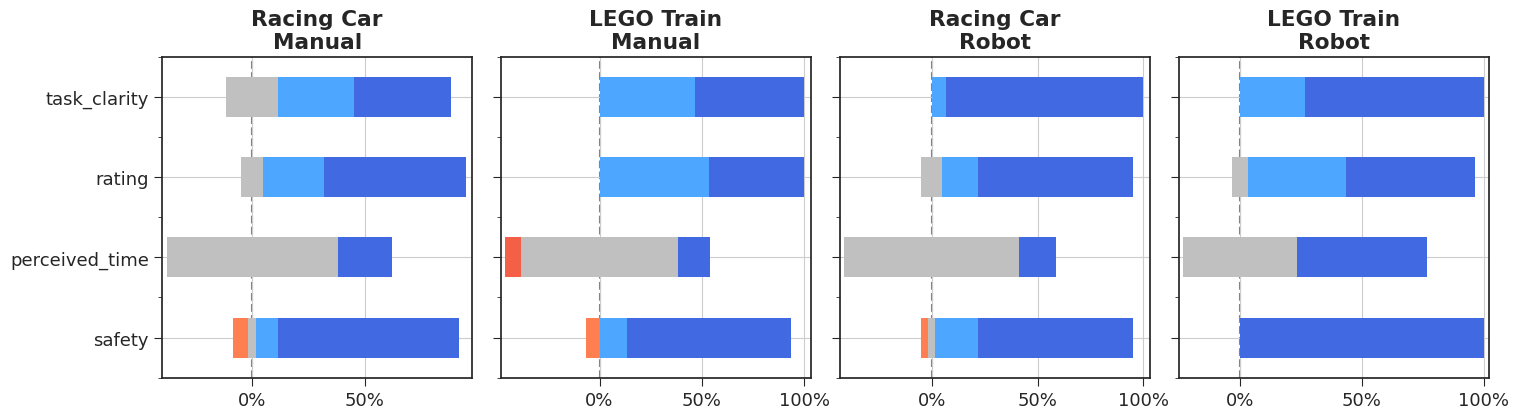

/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(


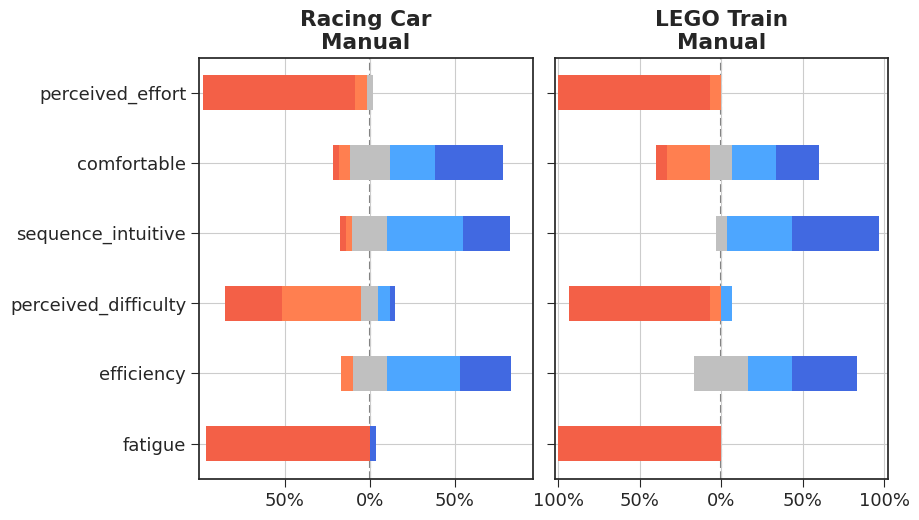

/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(
/home/bportelli/venv8/lib/python3.8/site-packages/plot_likert/plot_likert.py:313: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(


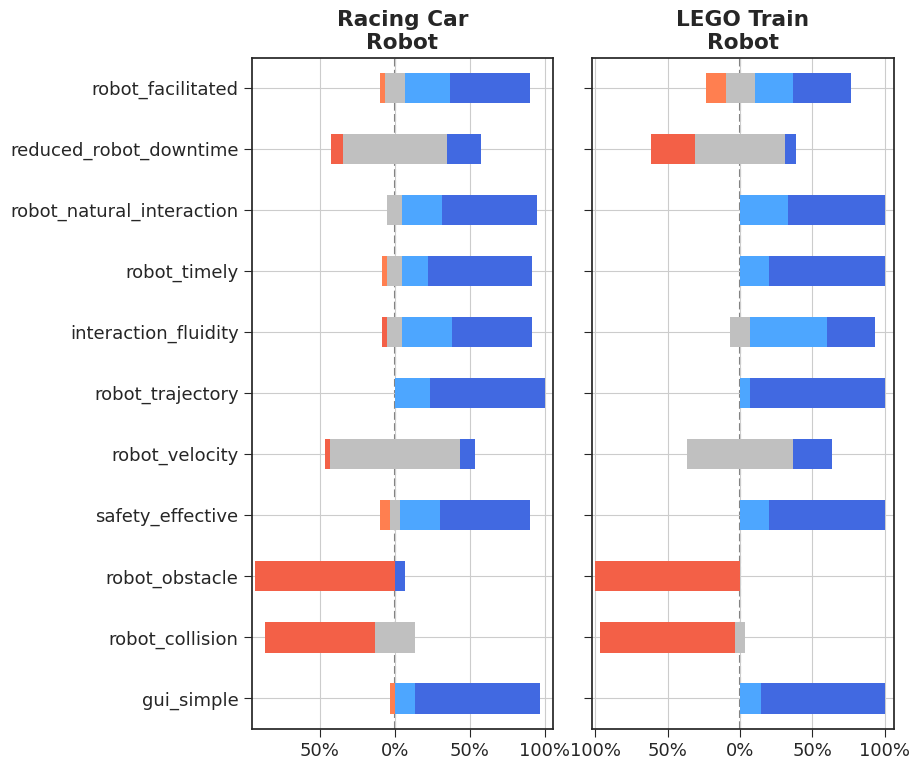

In [60]:
plt.style.use('seaborn-v0_8-ticks')
font = {
    'size' : 13
}
mpl.rc('font', **font)

colors = {
    "1": "#F36047",
    "2": "coral",
    "3": "silver",
    "4": "#4da6ff",
    "5": "RoyalBlue",
}
# colors = {
#     "1": "firebrick",
#     "2": "lightcoral",
#     "3": "silver",
#     "4": "cornflowerblue",
#     "5": "darkblue",
# }

VAR_GROUPS = [
    [
        "task_clarity",
        "rating",
        "perceived_time",
        "safety",
    ],
    [
        "perceived_effort",
        "comfortable",
        "sequence_intuitive",
        "perceived_difficulty",
        "efficiency",
        "fatigue",
    ],
    [
        "robot_facilitated",
        "reduced_robot_downtime",
        "robot_natural_interaction",
        "robot_timely",
        "interaction_fluidity",
        "robot_trajectory",
        "robot_velocity",
        "safety_effective",
        "robot_obstacle",
        "robot_collision",
        "gui_simple",
    ]
]

for var_group in VAR_GROUPS:

    data = df_concat.copy().loc[var_group]

    nonzero = (data.groupby(["SETUP", "PRODUCT"]).agg(sum).sum(axis=1)!=0).sum()

    fig, axs = plt.subplots(nrows=1, ncols=nonzero, figsize=(3+3*nonzero, 2+len(data)/8), sharey=True)

    idx=0
    for (PRODUCT, SETUP) in [
            ("Racing Car", "Manual"),
            ("LEGO Train", "Manual"),
            ("Racing Car", "Robot"),
            ("LEGO Train", "Robot"),
        ]:
        
        gdata = data[(data.SETUP==SETUP)&(data.PRODUCT==PRODUCT)]
        gdata = gdata[["1","2","3","4","5"]]

        if gdata.sum().sum()==0:
            continue
        
        ax = axs[idx]
        
        plot_likert.plot_counts(
            gdata.fillna(0),
            gdata.columns,
            ax=ax,
            legend=False,
            colors=[TRANSPARENT]+[colors[c] for c in gdata.columns],
            compute_percentages=True,
            xtick_interval=50,
        )

        # for k in [1.5, 5.5, 12.5, 15.5, 18.5]:
        #     ax.axhline(k, lw=1, color="k")
        ax.set_title(f"{PRODUCT}\n{SETUP}", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        ax.grid(True)
        if idx != 0:
            pass
        idx+=1
    # plt.legend()
    plt.tight_layout(pad=0.0)
    plt.show()

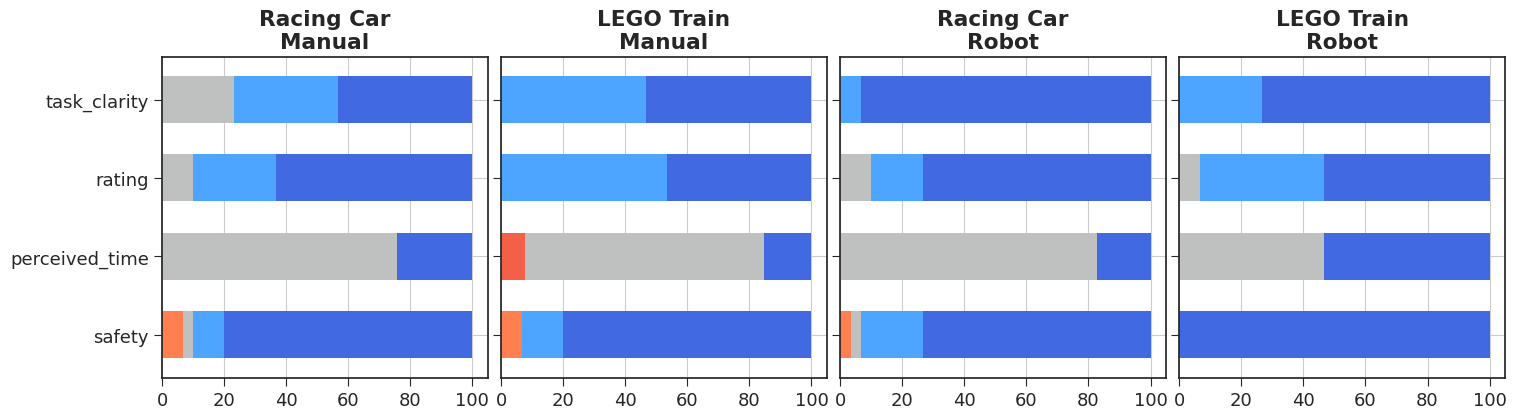

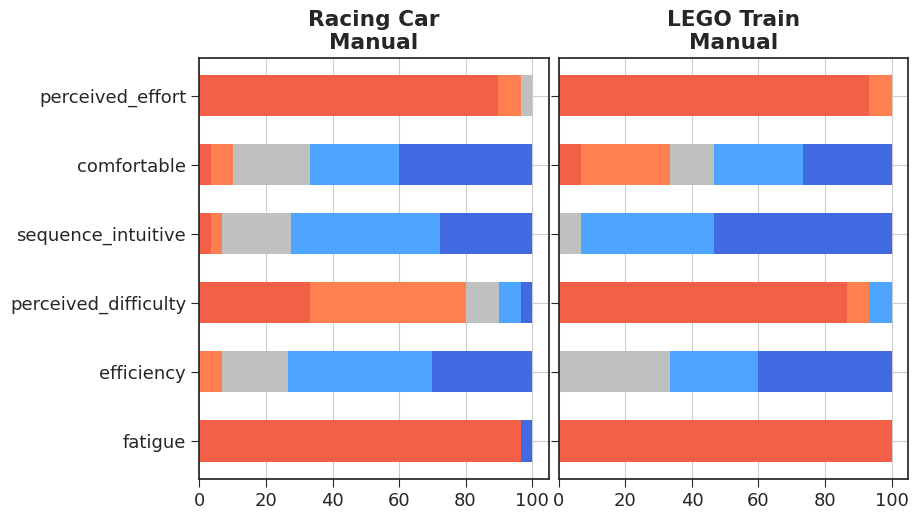

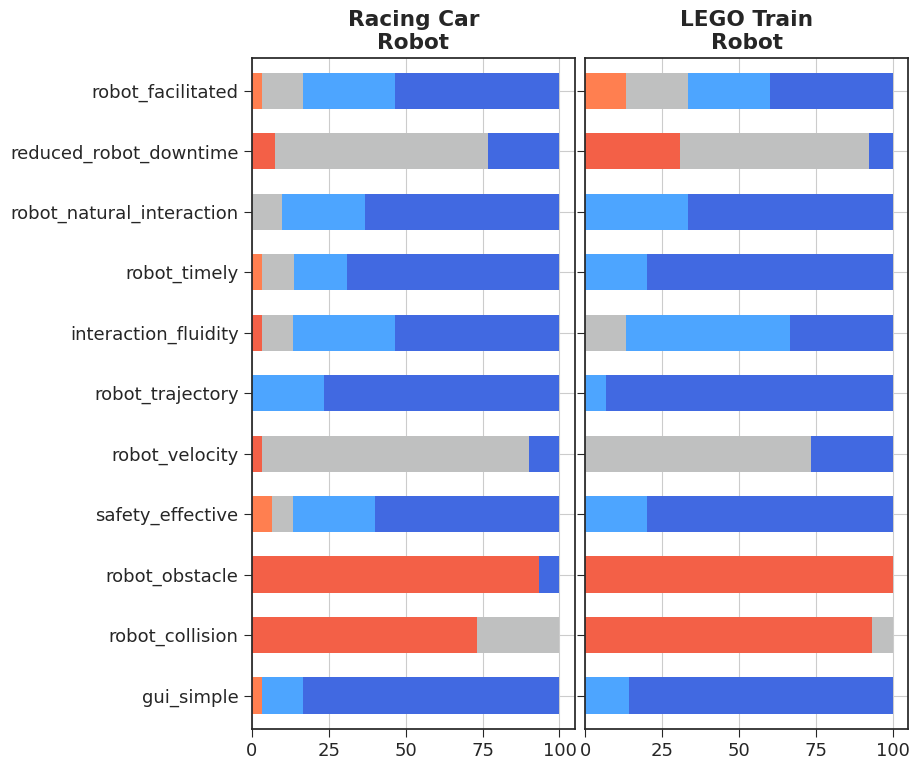

In [59]:
from matplotlib.colors import LinearSegmentedColormap

# Define your custom color palette
custom_colors = list(colors.values())

# Create a ListedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", custom_colors)
custom_cmap

plt.style.use('seaborn-v0_8-ticks')
font = {
    'size' : 13
}
mpl.rc('font', **font)

colors = {
    "1": "#F36047",
    "2": "coral",
    "3": "silver",
    "4": "#4da6ff",
    "5": "RoyalBlue",
}
# colors = {
#     "1": "firebrick",
#     "2": "lightcoral",
#     "3": "silver",
#     "4": "cornflowerblue",
#     "5": "darkblue",
# }

VAR_GROUPS = [
    [
        "task_clarity",
        "rating",
        "perceived_time",
        "safety",
    ],
    [
        "perceived_effort",
        "comfortable",
        "sequence_intuitive",
        "perceived_difficulty",
        "efficiency",
        "fatigue",
    ],
    [
        "robot_facilitated",
        "reduced_robot_downtime",
        "robot_natural_interaction",
        "robot_timely",
        "interaction_fluidity",
        "robot_trajectory",
        "robot_velocity",
        "safety_effective",
        "robot_obstacle",
        "robot_collision",
        "gui_simple",
    ]
]

for var_group in VAR_GROUPS:

    data = df_concat.copy().loc[var_group]

    nonzero = (data.groupby(["SETUP", "PRODUCT"]).agg(sum).sum(axis=1)!=0).sum()

    fig, axs = plt.subplots(nrows=1, ncols=nonzero, figsize=(3+3*nonzero, 2+len(data)/8), sharey=True)

    idx=0
    for (PRODUCT, SETUP) in [
            ("Racing Car", "Manual"),
            ("LEGO Train", "Manual"),
            ("Racing Car", "Robot"),
            ("LEGO Train", "Robot"),
        ]:
        
        gdata = data[(data.SETUP==SETUP)&(data.PRODUCT==PRODUCT)]
        gdata = gdata[["1","2","3","4","5"]]

        if gdata.sum().sum()==0:
            continue
        
        ax = axs[idx]
        
        gdata = gdata.apply(lambda row: row/row.sum()*100, axis=1)
        gdata = gdata[::-1]
        gdata.plot(kind="barh", stacked=True, cmap=custom_cmap, ax=ax, legend=False, width=.6)

        # for k in [1.5, 5.5, 12.5, 15.5, 18.5]:
        #     ax.axhline(k, lw=1, color="k")
        ax.set_title(f"{PRODUCT}\n{SETUP}", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        ax.grid(True)
        if idx != 0:
            pass
        idx+=1
    # plt.legend()
    plt.tight_layout(pad=0.0)
    plt.show()